In [1]:
import glob, json, math, os
import numpy as np, pandas as pd
from sklearn.metrics import roc_curve

def find(name):
    hits = glob.glob(f"/kaggle/input/**/{name}", recursive=True)
    assert hits, f"{name} not found. Check that all three inputs are added."
    return hits[0]

res = pd.read_csv(find("localization_results.csv"))
preds = pd.read_csv(find("predictions.csv"))
val = preds[preds.split == "val"]
fpr, tpr, thr = roc_curve(val.target, val.prob)
T = float(thr[np.argmax(tpr - fpr)])            

caught = res[res.said_pneumonia]                 
missed = res[~res.said_pneumonia]                
print(f"Patients: {len(res)} | caught: {len(caught)} | missed: {len(missed)} | threshold {T:.3f}")

rng = np.random.default_rng(42)
B = 2000

def with_ci(m):
    """Average of every column of m, with a 95% bootstrap confidence interval (patients resampled)."""
    v = m.to_numpy(dtype=float)
    boot = np.array([v[rng.integers(0, len(v), len(v))].mean(axis=0) for _ in range(B)])
    return pd.DataFrame({"estimate": v.mean(axis=0), "ci_low": np.quantile(boot, 0.025, axis=0),
                         "ci_high": np.quantile(boot, 0.975, axis=0)}, index=m.columns).round(3)

def scores(d, kind):
    """Per-patient scores for the three methods, plus the paired differences between them."""
    g, o, u = d[f"gradcam_{kind}"].astype(float), d[f"occlusion_{kind}"].astype(float), d[f"usual_{kind}"].astype(float)
    return pd.DataFrame({"Grad-CAM": g, "Occlusion": o, "Baseline: usual location": u, "Random guess (box share)": d.box_share,
                         "Grad-CAM minus baseline": g - u, "Occlusion minus baseline": o - u, "Grad-CAM minus occlusion": g - o})

tables = {}
for name, d in [("caught", caught), ("all", res), ("missed", missed)]:
    for kind, label in [("hit", "HOTTEST POINT inside a box"), ("overlap", "OVERLAP with boxes")]:
        t = with_ci(scores(d, kind))
        tables[f"{name}_{kind}"] = t
        print(f"\n{label} | {name} patients ({len(d)})")
        print(t.to_string())

pd.concat(tables).to_csv("/kaggle/working/localization_summary.csv")

h = caught[caught.control_clean]
hide = pd.DataFrame({
    "Probability: original image": h.prob,
    "Probability: boxes hidden": h.prob_boxes_hidden,
    "Probability: other area hidden": h.prob_control_hidden,
    "Drop when boxes hidden": h.prob - h.prob_boxes_hidden,
    "Drop when other area hidden": h.prob - h.prob_control_hidden,
    "Difference between the two drops": h.prob_control_hidden - h.prob_boxes_hidden,
    "No longer called pneumonia: boxes hidden": (h.prob_boxes_hidden < T).astype(float),
    "No longer called pneumonia: other area hidden": (h.prob_control_hidden < T).astype(float),
})
hide_table = with_ci(hide)
print(f"\nHIDING TEST | caught patients with a box-free control position ({len(h)})")
print(hide_table.to_string())
hide_table.to_csv("/kaggle/working/hiding_test.csv")

Patients: 1203 | caught: 959 | missed: 244 | threshold 0.212

HOTTEST POINT inside a box | caught patients (959)
                          estimate  ci_low  ci_high
Grad-CAM                     0.750   0.721    0.777
Occlusion                    0.626   0.595    0.657
Baseline: usual location     0.604   0.574    0.636
Random guess (box share)     0.131   0.125    0.138
Grad-CAM minus baseline      0.146   0.106    0.181
Occlusion minus baseline     0.022  -0.018    0.063
Grad-CAM minus occlusion     0.124   0.092    0.153

OVERLAP with boxes | caught patients (959)
                          estimate  ci_low  ci_high
Grad-CAM                     0.514   0.499    0.530
Occlusion                    0.394   0.381    0.408
Baseline: usual location     0.462   0.446    0.476
Random guess (box share)     0.131   0.125    0.137
Grad-CAM minus baseline      0.053   0.033    0.074
Occlusion minus baseline    -0.067  -0.086   -0.047
Grad-CAM minus occlusion     0.120   0.110    0.130

HOTTEST PO

In [2]:
S = 384
prior = np.load(find("map_usual_location.npy"))
cams = np.load(find("maps_gradcam.npy")).astype("float32")     
occs = np.load(find("maps_occlusion.npy")).astype("float32")
usual_col = int(np.unravel_index(prior.argmax(), prior.shape)[1])
res["rects"] = res.boxes.apply(json.loads)
caught = res[res.said_pneumonia]

one = caught[caught.n_boxes == 1].copy()
one["box_on_left"] = one.rects.apply(lambda r: (r[0][0] + r[0][2]) / 2 < S / 2)     
side = pd.DataFrame({
    "Grad-CAM": ((one.gradcam_col < S / 2) == one.box_on_left).astype(float),
    "Occlusion": ((one.occlusion_col < S / 2) == one.box_on_left).astype(float),
    "Baseline: usual location": ((usual_col < S / 2) == one.box_on_left).astype(float),
})
side["Grad-CAM minus baseline"] = side["Grad-CAM"] - side["Baseline: usual location"]
side["Occlusion minus baseline"] = side["Occlusion"] - side["Baseline: usual location"]
side_table = with_ci(side)
print(f"CORRECT SIDE: hottest point in the same half of the image as the box | caught patients with one box ({len(one)})")
print(f"  (the box is in the left half of the image for {one.box_on_left.mean():.1%} of them)")
print(side_table.to_string())
side_table.to_csv("/kaggle/working/side_test.csv")

def boxes_covered(m, rects):
    """How many of the patient's boxes have at least 10% of their area inside the heatmap's hottest region."""
    small = [(x0 // 4, y0 // 4, math.ceil(x1 / 4), math.ceil(y1 / 4)) for x0, y0, x1, y1 in rects]    # 384 -> 96 pixels
    mask = np.zeros(m.shape, dtype=bool)
    for x0, y0, x1, y1 in small:
        mask[y0:y1, x0:x1] = True
    hot = np.zeros(m.size, dtype=bool)
    hot[np.argpartition(m.ravel(), -int(mask.sum()))[-int(mask.sum()):]] = True
    hot = hot.reshape(m.shape)
    return sum(hot[y0:y1, x0:x1].mean() >= 0.10 for x0, y0, x1, y1 in small)

two = caught[caught.n_boxes == 2]
prior_small = prior[::4, ::4]
cover = pd.DataFrame({
    "Grad-CAM": [boxes_covered(cams[i], r) for i, r in zip(two.index, two.rects)],
    "Occlusion": [boxes_covered(occs[i], r) for i, r in zip(two.index, two.rects)],
    "Baseline: usual location": [boxes_covered(prior_small, r) for r in two.rects],
})
cover_table = pd.DataFrame({c: cover[c].value_counts(normalize=True).reindex([2, 1, 0], fill_value=0) for c in cover}).T.round(3)
cover_table.columns = ["both boxes", "only one box", "neither box"]
print(f"\nTWO BOXES: how many does the heatmap's hottest region cover? | caught patients with two boxes ({len(two)})")
print(cover_table.to_string())
cover_table.to_csv("/kaggle/working/two_box_coverage.csv")

caught = caught.assign(box_size=pd.qcut(caught.box_share, 3, labels=["small boxes", "medium boxes", "large boxes"]),
                       box_count=np.where(caught.n_boxes == 1, "one box", "two or more boxes"))
print("\nHOTTEST POINT inside a box, by patient group (caught patients)")
for col in ["view", "box_count", "box_size"]:
    g = caught.groupby(col, observed=True).agg(patients=("gradcam_hit", "size"), gradcam=("gradcam_hit", "mean"),
                                               occlusion=("occlusion_hit", "mean"), usual_location=("usual_hit", "mean"),
                                               random_guess=("box_share", "mean")).round(3)
    print(g.to_string(), "\n")

print("CAUGHT vs MISSED")
print(res.groupby("said_pneumonia").agg(patients=("prob", "size"), mean_box_share=("box_share", "mean"), two_or_more_boxes=("n_boxes", lambda s: (s > 1).mean()),
                                        gradcam_hit=("gradcam_hit", "mean"), usual_hit=("usual_hit", "mean")).rename(index={True: "caught", False: "missed"}).round(3).to_string())
print(f"\nGrad-CAM and occlusion agreement: caught {caught.methods_agree.mean():.3f} | missed {res[~res.said_pneumonia].methods_agree.mean():.3f}")
print("\nSaved:", sorted(f for f in os.listdir("/kaggle/working") if not f.startswith(".")))

CORRECT SIDE: hottest point in the same half of the image as the box | caught patients with one box (373)
  (the box is in the left half of the image for 59.8% of them)
                          estimate  ci_low  ci_high
Grad-CAM                     0.831   0.791    0.869
Occlusion                    0.855   0.820    0.890
Baseline: usual location     0.598   0.550    0.649
Grad-CAM minus baseline      0.233   0.166    0.295
Occlusion minus baseline     0.257   0.201    0.314

TWO BOXES: how many does the heatmap's hottest region cover? | caught patients with two boxes (560)
                          both boxes  only one box  neither box
Grad-CAM                       0.554         0.404        0.043
Occlusion                      0.446         0.530        0.023
Baseline: usual location       0.921         0.061        0.018

HOTTEST POINT inside a box, by patient group (caught patients)
      patients  gradcam  occlusion  usual_location  random_guess
view                             

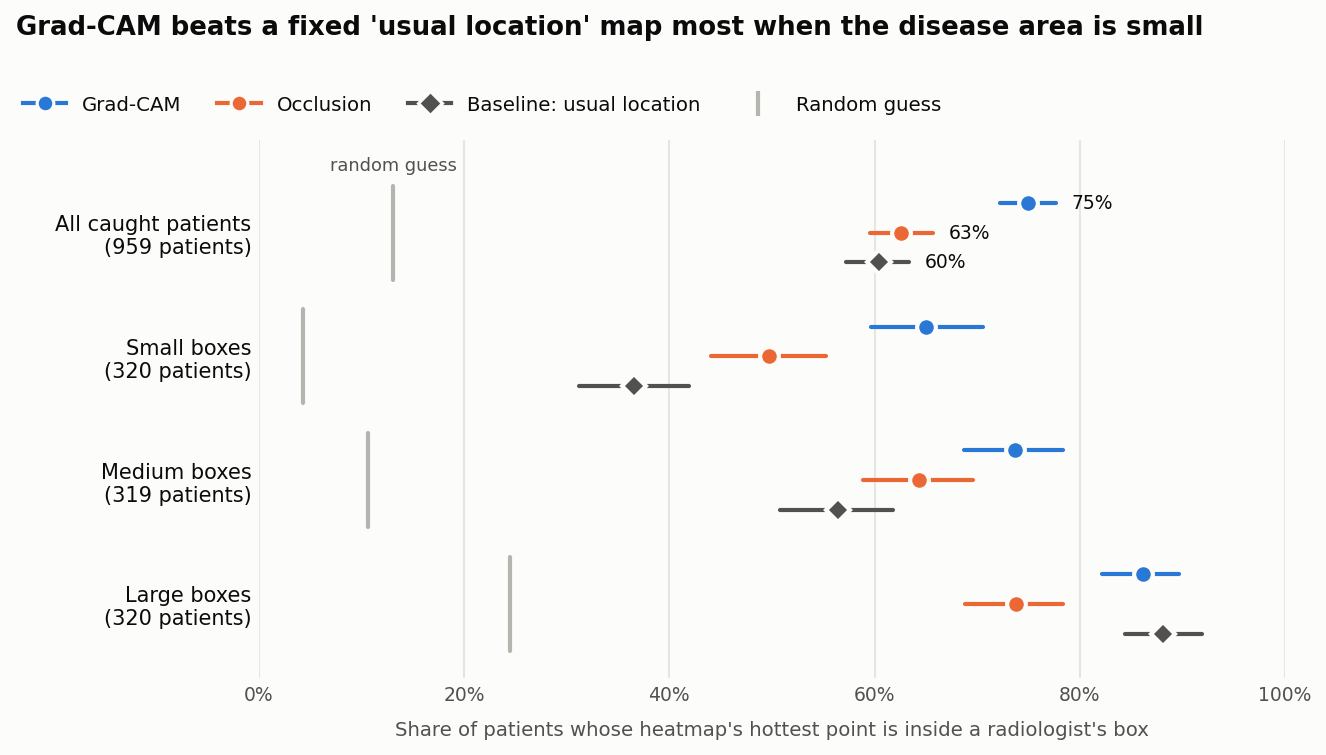

In [3]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

BLUE, ORANGE, GREY, LIGHT = "#2a78d6", "#eb6834", "#52514e", "#b5b4ae"
SURFACE, INK, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e6e5e0"

groups = [("All caught patients", caught)] + [(f"{size.capitalize()}", caught[caught.box_size == size])
                                              for size in ["small boxes", "medium boxes", "large boxes"]]
series = [("Grad-CAM", BLUE, "o", 0.24), ("Occlusion", ORANGE, "o", 0.0), ("Baseline: usual location", GREY, "D", -0.24)]

fig, ax = plt.subplots(figsize=(9, 5.2), dpi=150)
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
chart_rows = []
for gi, (label, d) in enumerate(groups):
    y0 = len(groups) - 1 - gi
    t = with_ci(scores(d, "hit")) * 100
    ax.plot([t.loc["Random guess (box share)", "estimate"]] * 2, [y0 - 0.38, y0 + 0.38], color=LIGHT, lw=2, solid_capstyle="round", zorder=1)
    for name, colour, marker, dy in series:
        est, lo, hi = t.loc[name, ["estimate", "ci_low", "ci_high"]]
        ax.plot([lo, hi], [y0 + dy] * 2, color=colour, lw=2, solid_capstyle="round", zorder=2)
        ax.plot(est, y0 + dy, marker=marker, ms=9 if marker == "o" else 8, color=colour, mec=SURFACE, mew=2, zorder=3)
        if gi == 0:
            ax.text(hi + 1.5, y0 + dy, f"{est:.0f}%", va="center", ha="left", fontsize=9, color=INK)
        chart_rows.append({"group": label, "patients": len(d), "method": name, "percent": est, "ci_low": lo, "ci_high": hi})
    if gi == 0:
        ax.text(t.loc["Random guess (box share)", "estimate"], y0 + 0.47, "random guess", ha="center", va="bottom", fontsize=8.5, color=MUTED)

ax.set_yticks(range(len(groups)))
ax.set_yticklabels([f"{label}\n({len(d)} patients)" for label, d in groups][::-1], fontsize=10, color=INK)
ax.set_xlim(0, 100); ax.set_ylim(-0.6, len(groups) - 0.25)
ax.set_xticks(range(0, 101, 20)); ax.set_xticklabels([f"{v}%" for v in range(0, 101, 20)], fontsize=9, color=MUTED)
ax.set_xlabel("Share of patients whose heatmap's hottest point is inside a radiologist's box", fontsize=9.5, color=MUTED, labelpad=8)
ax.grid(axis="x", color=GRID, lw=1); ax.set_axisbelow(True)
ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)

handles = [Line2D([], [], color=c, marker=m, ms=8, mec=SURFACE, mew=1.5, lw=2, label=n) for n, c, m, _ in series]
handles.append(Line2D([], [], color=LIGHT, marker="|", ms=12, mew=2, lw=0, label="Random guess"))
fig.legend(handles=handles, loc="upper left", bbox_to_anchor=(0.012, 0.9), ncol=4, frameon=False, fontsize=9.5, labelcolor=INK,
           handlelength=2.2, columnspacing=1.8)
fig.text(0.02, 0.955, "Grad-CAM beats a fixed 'usual location' map most when the disease area is small",
         fontsize=12.5, color=INK, weight="bold", ha="left")
fig.subplots_adjust(left=0.2, right=0.96, top=0.82, bottom=0.13)
fig.savefig("/kaggle/working/hit_rate_by_box_size.png", dpi=150, facecolor=SURFACE)
pd.DataFrame(chart_rows).round(1).to_csv("/kaggle/working/hit_rate_by_box_size.csv", index=False)
plt.show()

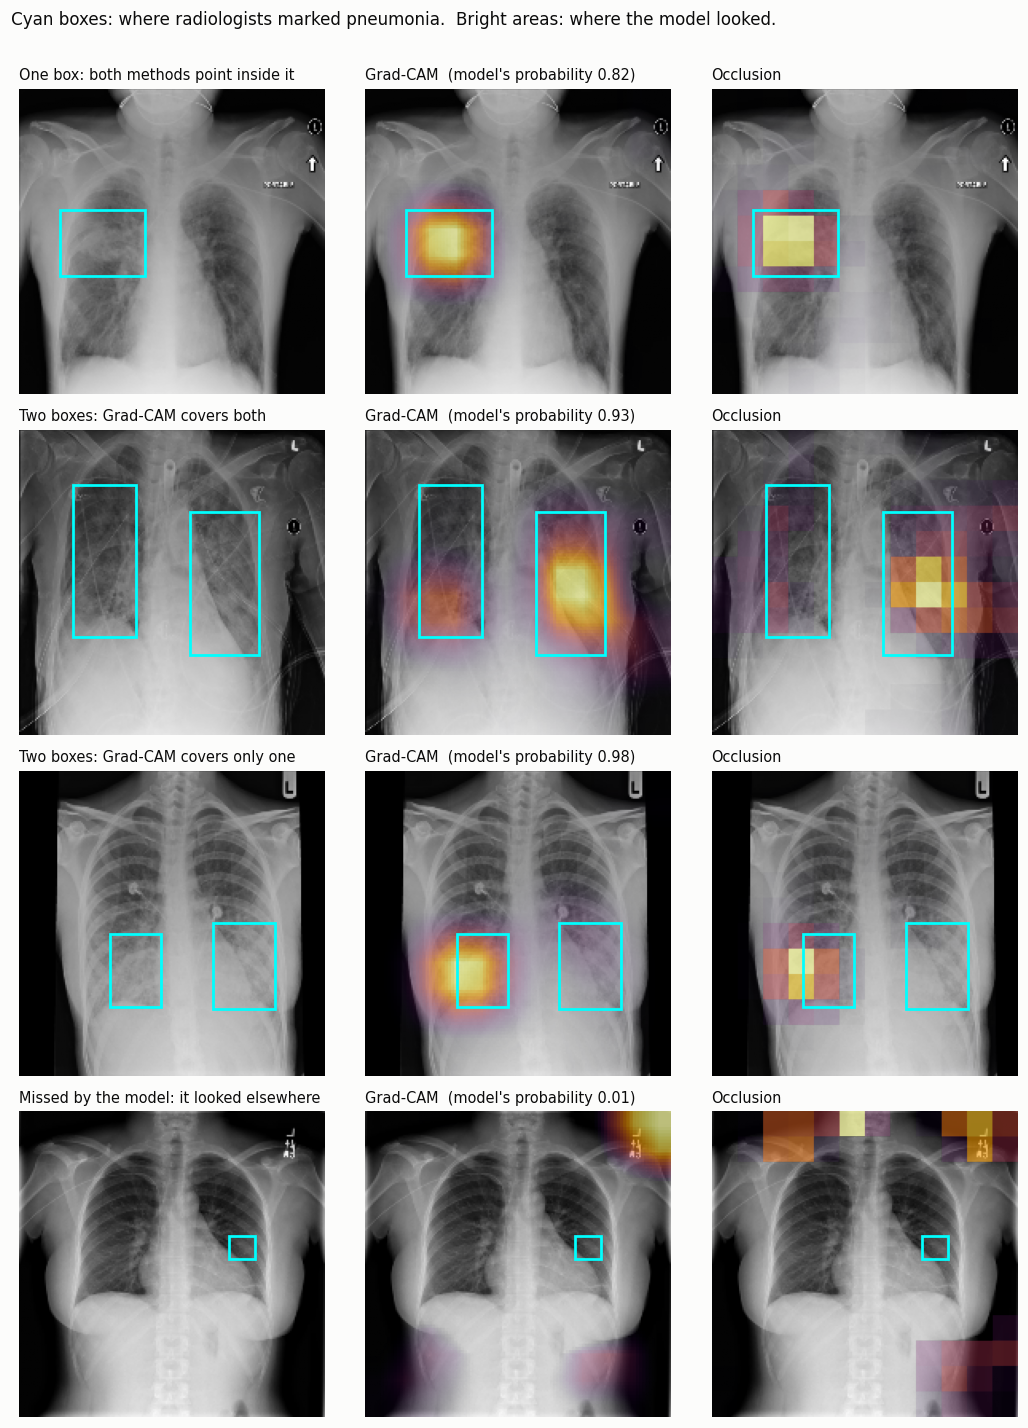

Patients shown (the first in file order that fit each description): ['05dad446-45f7-44df-bd2f-4673d9502348', '00f08de1-517e-4652-a04f-d1dc9ee48593', '00c0b293-48e7-4e16-ac76-9269ba535a62', '0100515c-5204-4f31-98e0-f35e4b00004a']
Saved: ['__notebook__.ipynb', 'examples_grid.png', 'hiding_test.csv', 'hit_rate_by_box_size.csv', 'hit_rate_by_box_size.png', 'localization_summary.csv', 'side_test.csv', 'two_box_coverage.csv']


In [4]:
import matplotlib.patches as patches

images = np.load(find("images_384.npy"), mmap_mode="r")
idx_of = preds.set_index("patientId").idx

two_c = two.assign(gradcam_boxes=cover["Grad-CAM"].values)
missed_now = res[~res.said_pneumonia]
cases = [
    ("One box: both methods point inside it", caught[(caught.n_boxes == 1) & caught.gradcam_hit & caught.occlusion_hit].index[0]),
    ("Two boxes: Grad-CAM covers both", two_c[two_c.gradcam_boxes == 2].index[0]),
    ("Two boxes: Grad-CAM covers only one", two_c[two_c.gradcam_boxes == 1].index[0]),
    ("Missed by the model: it looked elsewhere", missed_now[~missed_now.gradcam_hit & ~missed_now.occlusion_hit].index[0]),
]

fig, axes = plt.subplots(len(cases), 3, figsize=(9.6, 3.3 * len(cases)), dpi=110)
fig.patch.set_facecolor(SURFACE)
for row, (label, i) in zip(axes, cases):
    r = res.loc[i]
    img = np.array(images[idx_of[r.patientId]])[::2, ::2]                          # 192 x 192
    for ax, (title, m) in zip(row, [(label, None), ("Grad-CAM", cams[i]), ("Occlusion", occs[i])]):
        ax.imshow(img, cmap="gray", vmin=0, vmax=255)
        if m is not None:
            m = np.kron(np.clip(m, 0, None), np.ones((2, 2)))                      # 96 -> 192 pixels
            m = m / m.max() if m.max() > 0 else m
            layer = plt.cm.inferno(m)
            layer[..., 3] = 0.75 * m                                               # see-through where the heat is low
            ax.imshow(layer)
        for x0, y0, x1, y1 in r.rects:
            ax.add_patch(patches.Rectangle((x0 / 2, y0 / 2), (x1 - x0) / 2, (y1 - y0) / 2, fill=False, edgecolor="cyan", linewidth=1.8))
        ax.set_title(title if m is None else f"{title}  (model's probability {r.prob:.2f})" if title == "Grad-CAM" else title,
                     fontsize=9.5, color=INK, loc="left")
        ax.axis("off")
fig.suptitle("Cyan boxes: where radiologists marked pneumonia.  Bright areas: where the model looked.", fontsize=11, color=INK, x=0.02, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.975))
fig.savefig("/kaggle/working/examples_grid.png", dpi=110, facecolor=SURFACE)
plt.show()
print("Patients shown (the first in file order that fit each description):", [res.patientId[i] for _, i in cases])
print("Saved:", sorted(f for f in os.listdir("/kaggle/working") if not f.startswith(".")))

In [5]:
def near_edge(d, method, margin=0.10):
    """1 if the heatmap's hottest point is within 10% of the image border, where there is no lung."""
    row, col, m = d[f"{method}_row"], d[f"{method}_col"], S * margin
    return ((row < m) | (row >= S - m) | (col < m) | (col >= S - m)).astype(float)

print("HOTTEST POINT NEAR THE EDGE OF THE IMAGE (a random point would be there 36% of the time)")
edge_tables = {}
for name, d in [("caught", res[res.said_pneumonia]), ("missed", res[~res.said_pneumonia])]:
    t = with_ci(pd.DataFrame({"Grad-CAM": near_edge(d, "gradcam"), "Occlusion": near_edge(d, "occlusion")}))
    edge_tables[name] = t
    print(f"\n{name} patients ({len(d)})")
    print(t.to_string())
pd.concat(edge_tables).to_csv("/kaggle/working/edge_test.csv")

HOTTEST POINT NEAR THE EDGE OF THE IMAGE (a random point would be there 36% of the time)

caught patients (959)
           estimate  ci_low  ci_high
Grad-CAM      0.031   0.020    0.044
Occlusion     0.096   0.078    0.115

missed patients (244)
           estimate  ci_low  ci_high
Grad-CAM      0.422   0.365    0.488
Occlusion     0.512   0.451    0.574


In [6]:
import shutil

out = "/kaggle/working/github"
os.makedirs(f"{out}/results", exist_ok=True); os.makedirs(f"{out}/data", exist_ok=True)

pd.read_csv(find("splits.csv"))[["patientId", "split"]].to_csv(f"{out}/data/splits.csv", index=False)

res.drop(columns=["boxes", "rects", "age", "sex", "view"]).to_csv(f"{out}/results/localization_results.csv", index=False)

for f in ["localization_summary.csv", "hiding_test.csv", "side_test.csv", "two_box_coverage.csv", "edge_test.csv",
          "hit_rate_by_box_size.csv", "hit_rate_by_box_size.png", "examples_grid.png"]:
    shutil.copy(f"/kaggle/working/{f}", f"{out}/results/{f}")

for f in ["training_log.json", "classifier_metrics.csv", "calibration_table.csv"]:    
    hits = glob.glob(f"/kaggle/input/**/{f}", recursive=True)
    if hits:
        shutil.copy(hits[0], f"{out}/results/{f}")
    else:
        print(f"NOT FOUND: {f}. Add the notebook that made it as an input, then run this cell again.")

shutil.make_archive("/kaggle/working/github_files", "zip", out)
print("In the zip:", sorted(os.path.relpath(os.path.join(d, f), out) for d, _, fs in os.walk(out) for f in fs))

In the zip: ['data/splits.csv', 'results/calibration_table.csv', 'results/classifier_metrics.csv', 'results/edge_test.csv', 'results/examples_grid.png', 'results/hiding_test.csv', 'results/hit_rate_by_box_size.csv', 'results/hit_rate_by_box_size.png', 'results/localization_results.csv', 'results/localization_summary.csv', 'results/side_test.csv', 'results/training_log.json', 'results/two_box_coverage.csv']
